In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import product
from statsmodels.tsa.statespace.structural import UnobservedComponents

#### Transformations of variables
Transform with taking the logarithm of: screen and all apps (without finance, weather)

In [2]:
transform_vars = ['screen', 'appCat.builtin', 'appCat.communication',
       'appCat.entertainment', 'appCat.game',
       'appCat.office', 'appCat.other', 'appCat.social', 'appCat.travel',
       'appCat.unknown', 'appCat.utilities']

df_median_imputed = pd.read_csv('df_median.csv')
df_kalman_imputed = pd.read_csv('df_kalman.csv')

df_median_imputed['value'] = np.where(
    df_median_imputed['variable'].isin(transform_vars),
    np.log1p(df_median_imputed['value']),
    df_median_imputed['value']
    )

df_kalman_imputed['value'] = np.where(
    df_kalman_imputed['variable'].isin(transform_vars),
    np.log1p(df_kalman_imputed['value']),
    df_kalman_imputed['value']
    )


/Users/lauradevries/Data mining/DM-Assignment-1/venv/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/lauradevries/Data mining/DM-Assignment-1/venv/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


#### Pivoting: adding missing days, fixing NaNs with zeros and sums

In [3]:
def pivot_df(df_imputed, imputed_vars, name='median'):

    # ids and dates
    ids = df_imputed['id'].unique()
    df_imputed['date'] = pd.to_datetime(df_imputed['date']) 

    # summing
    sum_vars = [v for v in df_imputed['variable'].unique() if v not in imputed_vars]  
    median_group = df_imputed[df_imputed['variable'].isin(imputed_vars)].copy()
    median_agg = (median_group.groupby(['id', 'date', 'variable'])['value'].agg(lambda x: x.mean() if 'mood' in x.name else x.median()).reset_index())
    
    sum_group = df_imputed[df_imputed['variable'].isin(sum_vars)].copy()
    sum_agg = (sum_group.groupby(['id', 'date', 'variable'])['value'].sum().reset_index())

    # pivot and combine
    combined = pd.concat([median_agg, sum_agg], ignore_index=True)
    daily_df = combined.pivot(index=['id', 'date'], columns='variable', values='value').reset_index()
    daily_df.columns.name = None

    # fill in 0 for sumtype variables
    all_columns = daily_df.columns.tolist()
    cols_to_fill = [col for col in all_columns if col not in imputed_vars and col not in ['id', 'date']]
    daily_df[cols_to_fill] = daily_df[cols_to_fill].fillna(0)
    print(f"{name} dataset: shape before adding missing dates = {daily_df.shape}")
    
    # missing dates per used added
    all_dates = pd.date_range(daily_df['date'].min(), daily_df['date'].max())
    full_index = pd.MultiIndex.from_product([ids, all_dates], names=['id', 'date'])
    daily_df_full = daily_df.set_index(['id', 'date']).reindex(full_index).reset_index()

    print(f"{name} dataset: shape after adding missing dates = {daily_df_full.shape}")
    display(daily_df_full.head())
    return daily_df, daily_df_full


#### Missing values of apps comparison

In [4]:
# imputed variables
imputed_vars = ['mood', 'circumplex.arousal', 'circumplex.valence', 'activity']

# use function made previously
daily_df_median_raw, daily_df_median_full = pivot_df(df_median_imputed, imputed_vars, name='median')
daily_df_kalman_raw, daily_df_kalman_full = pivot_df(df_kalman_imputed, imputed_vars, name='kalman')

# to compare later shapes
print("Before trimming:")
print("median shape:", daily_df_median_full.shape)
print("kalman shape:", daily_df_kalman_full.shape)


median dataset: shape before adding missing dates = (1973, 21)
median dataset: shape after adding missing dates = (3051, 21)


,id,date,activity,appCat.builtin,appCat.communication,appCat.entertainment,appCat.finance,appCat.game,appCat.office,appCat.other,...,appCat.travel,appCat.unknown,appCat.utilities,appCat.weather,call,circumplex.arousal,circumplex.valence,mood,screen,sms
0,AS14.01,2014-02-17,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,2.0,NaN,NaN,NaN,0.0,0.0
1,AS14.01,2014-02-18,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,NaN,NaN,NaN,0.0,0.0
2,AS14.01,2014-02-19,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,7.0,NaN,NaN,NaN,0.0,2.0
3,AS14.01,2014-02-20,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,2.0,NaN,NaN,NaN,0.0,3.0
4,AS14.01,2014-02-21,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,0.0,1.0


kalman dataset: shape before adding missing dates = (1973, 21)
kalman dataset: shape after adding missing dates = (3051, 21)


,id,date,activity,appCat.builtin,appCat.communication,appCat.entertainment,appCat.finance,appCat.game,appCat.office,appCat.other,...,appCat.travel,appCat.unknown,appCat.utilities,appCat.weather,call,circumplex.arousal,circumplex.valence,mood,screen,sms
0,AS14.01,2014-02-17,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,2.0,NaN,NaN,NaN,0.0,0.0
1,AS14.01,2014-02-18,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,NaN,NaN,NaN,0.0,0.0
2,AS14.01,2014-02-19,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,7.0,NaN,NaN,NaN,0.0,2.0
3,AS14.01,2014-02-20,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,2.0,NaN,NaN,NaN,0.0,3.0
4,AS14.01,2014-02-21,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,0.0,1.0


Before trimming:
median shape: (3051, 21)
kalman shape: (3051, 21)


In [5]:
daily_df_median_raw[imputed_vars].isna().sum(), daily_df_kalman_raw[imputed_vars].isna().sum()


(mood                  705
 circumplex.arousal    705
 circumplex.valence    705
 activity              785
 dtype: int64,
 mood                  705
 circumplex.arousal    705
 circumplex.valence    705
 activity              785
 dtype: int64)

In [6]:
daily_df_median_full[imputed_vars].isna().sum(), daily_df_kalman_full[imputed_vars].isna().sum()

(mood                  1783
 circumplex.arousal    1783
 circumplex.valence    1783
 activity              1863
 dtype: int64,
 mood                  1783
 circumplex.arousal    1783
 circumplex.valence    1783
 activity              1863
 dtype: int64)

#### Trimming the dataset till last known mood entry

In [7]:
# trimming till last known mood for median method
if 'mood' in daily_df_median_full.columns:
    last_mood_dates = (
        daily_df_median_full[~daily_df_median_full['mood'].isna()]
        .groupby('id')['date'].max()
    )

    daily_df_median_full = daily_df_median_full.merge(
        last_mood_dates.rename('last_mood_date'), on='id', how='left'
    )
    daily_df_median_full = daily_df_median_full[daily_df_median_full['date'] <= daily_df_median_full['last_mood_date']]
    daily_df_median_full.drop(columns='last_mood_date', inplace=True)


# trimming till last known mood for kalman method
if 'mood' in daily_df_kalman_full.columns:
    last_mood_dates = (
        daily_df_kalman_full[~daily_df_kalman_full['mood'].isna()]
        .groupby('id')['date'].max()
    )

    daily_df_kalman_full = daily_df_kalman_full.merge(
        last_mood_dates.rename('last_mood_date'), on='id', how='left'
    )
    daily_df_kalman_full = daily_df_kalman_full[daily_df_kalman_full['date'] <= daily_df_kalman_full['last_mood_date']]
    daily_df_kalman_full.drop(columns='last_mood_date', inplace=True)

# print("\nAfter trimming:")
# print("median shape:", daily_df_median_full.shape)
# print("kalman shape:", daily_df_kalman_full.shape)


#### Imputation: two methods again (median and kalman)

##### Method 1: Average medians

In [8]:
# average median method
vars_to_impute = [col for col in daily_df_median_full.columns if col not in ['id', 'date']]

for var in vars_to_impute:
    if var == 'mood':
        daily_df_median_full['was_imputed'] = daily_df_median_full['mood'].isna()

    # average of previous and next day
    prev = daily_df_median_full.groupby('id')[var].shift(1)
    next_ = daily_df_median_full.groupby('id')[var].shift(-1)
    interpolated = (prev + next_) / 2
    daily_df_median_full[var] = daily_df_median_full[var].fillna(interpolated)

    # forward and backward fill
    daily_df_median_full[var] = (
        daily_df_median_full.groupby('id')[var]
        .apply(lambda x: x.ffill().bfill())
        .reset_index(level=0, drop=True)
    )

# daily_df_median_full.head()

In [9]:
missing_values = daily_df_median_full.isna().sum()
missing_values

id                      0
date                    0
activity                0
appCat.builtin          0
appCat.communication    0
appCat.entertainment    0
appCat.finance          0
appCat.game             0
appCat.office           0
appCat.other            0
appCat.social           0
appCat.travel           0
appCat.unknown          0
appCat.utilities        0
appCat.weather          0
call                    0
circumplex.arousal      0
circumplex.valence      0
mood                    0
screen                  0
sms                     0
was_imputed             0
dtype: int64

In [10]:
# Define rules per variable
rules = {
    'mood': lambda x: (x < 1) | (x > 10),
    'circumplex.arousal': lambda x: (x < -2) | (x > 2),
    'circumplex.valence': lambda x: (x < -2) | (x > 2),
    'activity': lambda x: (x < 0) | (x > 1),
}

# Add all duration-like columns
duration_vars = [col for col in daily_df_median_full.columns if col.startswith('appCat.') or col in ['screen', 'call', 'sms']]
for col in duration_vars:
    rules[col] = lambda x: x < 0

# Check each rule
print("Unrealistic values found:")
for var, rule in rules.items():
    if var in daily_df_median_full.columns:
        mask = rule(daily_df_median_full[var])
        n_unrealistic = mask.sum()
        if n_unrealistic > 0:
            print(f"{var}: {n_unrealistic} values")


Unrealistic values found:


##### Method 2: Kalman
Using kalman for non-binary and non-duration and use the median method for other variables

In [11]:
# variables we will do kalman on
kalman_vars = ['mood', 'circumplex.arousal', 'circumplex.valence', 'activity']

# kalman smoothing
def kalman_impute(series):
    if series.isnull().all(): # if all values are nan, keep nans dont do kalman
        return series

    model = UnobservedComponents(series, level='local level') #kalman
    result = model.fit(disp=False) # fit the model
    smoothed = result.smoothed_state[0] # get smoothed values from the fitted model
    series[series.isna()] = smoothed[series.isna()] # replace the missing values with the smoothed values
    
    return series

for var in kalman_vars:
    if var == 'mood':
        daily_df_kalman_full['was_imputed'] = daily_df_kalman_full['mood'].isna()

    daily_df_kalman_full[var] = (
        daily_df_kalman_full.groupby('id')[var]
        .transform(kalman_impute)
    )

# after kalman apply fallback ffill + bfill for any still-missing kalman_vars
for var in kalman_vars:
    daily_df_kalman_full[var] = (
        daily_df_kalman_full.groupby('id')[var]
        .apply(lambda x: x.ffill().bfill())
        .reset_index(level=0, drop=True)
    )


/Users/lauradevries/Data mining/DM-Assignment-1/venv/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/Users/lauradevries/Data mining/DM-Assignment-1/venv/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/Users/lauradevries/Data mining/DM-Assignment-1/venv/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/Users/lauradevries/Data mining

In [12]:
non_kalman_vars = [col for col in daily_df_kalman_full.columns if col not in kalman_vars + ['id', 'date']]

for var in non_kalman_vars:
    prev = daily_df_kalman_full.groupby('id')[var].shift(1)
    next_ = daily_df_kalman_full.groupby('id')[var].shift(-1)
    interpolated = (prev + next_) / 2
    daily_df_kalman_full[var] = daily_df_kalman_full[var].fillna(interpolated)

    daily_df_kalman_full[var] = (
        daily_df_kalman_full.groupby('id')[var]
        .apply(lambda x: x.ffill().bfill())
        .reset_index(level=0, drop=True)
    )

# daily_df_kalman_full.head()

In [13]:
missing_values_kalman = daily_df_kalman_full.isna().sum()
missing_values_kalman

id                      0
date                    0
activity                0
appCat.builtin          0
appCat.communication    0
appCat.entertainment    0
appCat.finance          0
appCat.game             0
appCat.office           0
appCat.other            0
appCat.social           0
appCat.travel           0
appCat.unknown          0
appCat.utilities        0
appCat.weather          0
call                    0
circumplex.arousal      0
circumplex.valence      0
mood                    0
screen                  0
sms                     0
was_imputed             0
dtype: int64

#### Atributes
Mood: trend
activity: mean
screen: trend
call: sum
sms: sum
apps: trend
arousal: trend
valence: trend

In [14]:
window_size = 5

def trend(x):
    return x.iloc[-1] - x.iloc[0] if len(x) > 1 else np.nan

def rolling_table(df_method):
    df_method = df_method.sort_values(by=['id','date'])

    results = []
    for user_id, group in df_method.groupby('id'):
        group = group.set_index('date').sort_index()
        res = pd.DataFrame(index=group.index)
        res['id'] = user_id

        res['mood_trend'] = group['mood'].rolling(window=window_size, min_periods=1).apply(trend)
        res['activity_mean'] = group['activity'].rolling(window=window_size, min_periods=1).mean()
        res['screen_mean'] = group['screen'].rolling(window=window_size, min_periods=1).mean()
        res['call_sum'] = group['call'].rolling(window=window_size, min_periods=1).sum()
        res['sms_sum'] = group['sms'].rolling(window=window_size, min_periods=1).sum()
        res['arousal_trend'] = group['circumplex.arousal'].rolling(window=window_size, min_periods=1).apply(trend)
        res['valence_trend'] = group['circumplex.valence'].rolling(window=window_size, min_periods=1).apply(trend)

        # Apply trend for all appCat.* variables
        for col in group.columns:
            if col.startswith('appCat.'):
                res[f'{col}_mean'] = group[col].rolling(window=window_size, min_periods=1).mean()

        results.append(res.reset_index())

    # Combine all users
    final_features_df = pd.concat(results).sort_values(by=['id', 'date']).reset_index(drop=True)

    return final_features_df

rolling_median = rolling_table(daily_df_median_full)
rolling_kalman = rolling_table(daily_df_kalman_full)

# Merge in target mood and imputation indicator
rolling_median = rolling_median.merge(
    daily_df_median_full[['id', 'date', 'mood', 'was_imputed']].rename(columns={'mood': 'mood'}),
    on=['id', 'date'], how='left'
)

rolling_kalman = rolling_kalman.merge(
    daily_df_kalman_full[['id', 'date', 'mood', 'was_imputed']].rename(columns={'mood': 'mood'}),
    on=['id', 'date'], how='left'
)


#### Trimming first 5 days (for prediction dataset)

In [15]:
# trimming first 5 days, for prediction dataset
# median method set
attribute_median = rolling_median.sort_values(['id', 'date']).copy()
attribute_median['day_index'] = attribute_median.groupby('id').cumcount()
attribute_median = attribute_median[attribute_median['day_index'] >= 5].drop(columns='day_index')

# kalman method set
attribute_kalman = rolling_kalman.sort_values(['id', 'date']).copy()
attribute_kalman['day_index'] = attribute_kalman.groupby('id').cumcount()
attribute_kalman = attribute_kalman[attribute_kalman['day_index'] >= 5].drop(columns='day_index')

#### Correlation between attributes

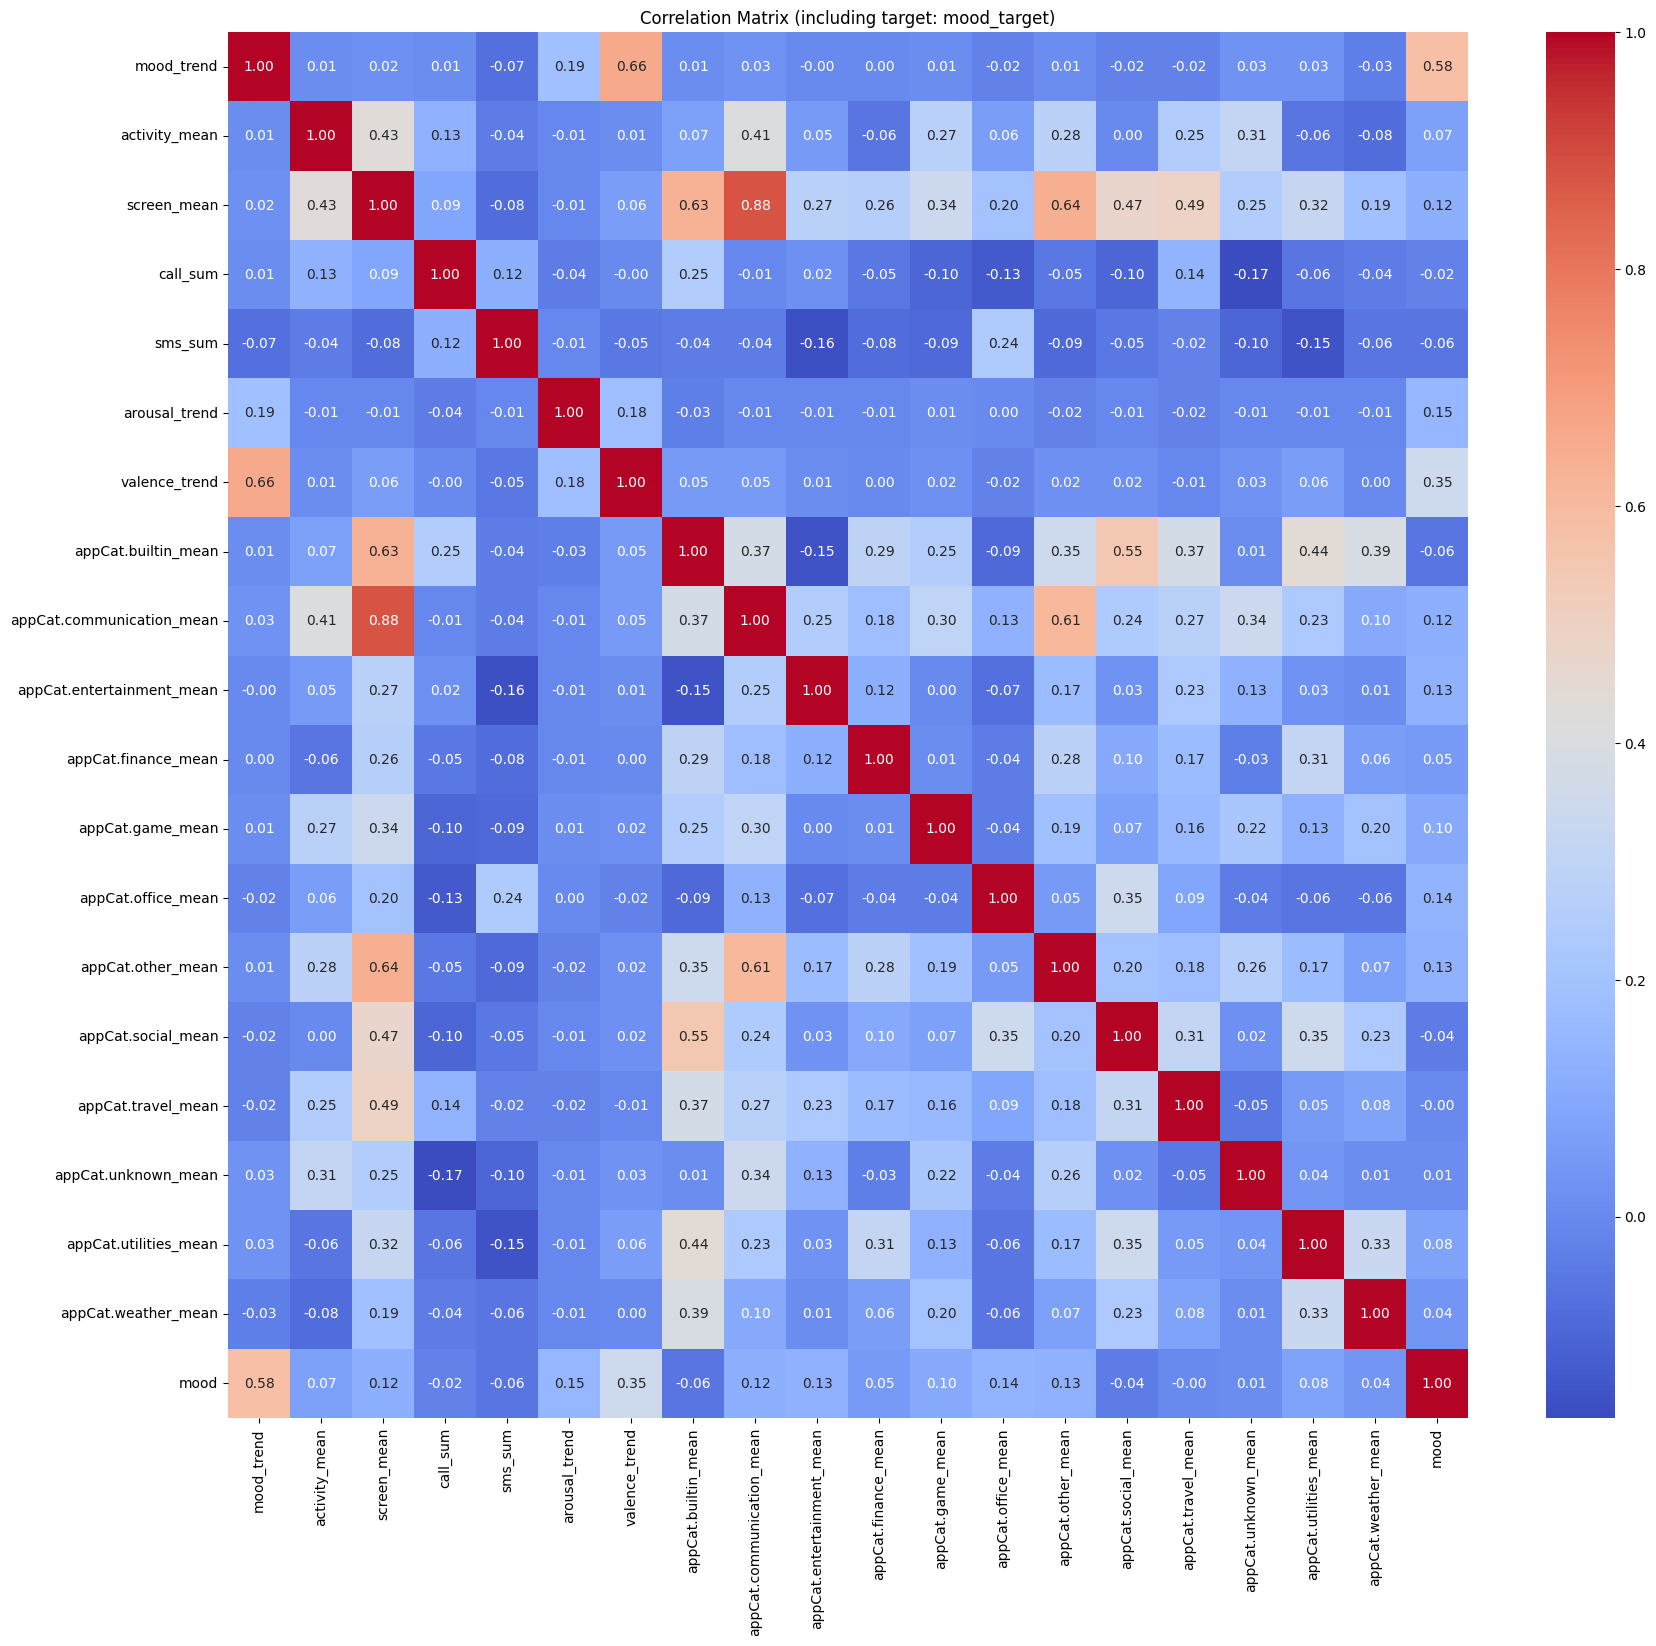

In [16]:
correlation_df_m = attribute_median.copy()
correlation_df_k = attribute_kalman.copy()

correlation_df_m = correlation_df_m[correlation_df_m['was_imputed'] == False]
correlation_df_k = correlation_df_k[correlation_df_k['was_imputed'] == False]

exclude_cols = ['id', 'date', 'was_imputed']  # optionally also 'mood_imputed' if you want
features_for_corr = correlation_df_m.drop(columns=exclude_cols)

# Compute correlation matrix
correlation_matrix = features_for_corr.corr()

# Optional: round for easier reading
correlation_matrix = correlation_matrix.round(2)

# Display the matrix
plt.figure(figsize=(20, 18))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Correlation Matrix (including target: mood_target)")
plt.show()

Delete un-correlated features: call, sms, activity, app builtin, finance, social, travel, unknown, utilities, weather

In [17]:
correlation_df_median = correlation_df_m.copy()
correlation_df_kalman = correlation_df_k.copy()

uncorrelated = ['call_sum', 'sms_sum', 'activity_mean', 'appCat.builtin_mean', 'appCat.finance_mean', 
                'appCat.social_mean', 'appCat.travel_mean', 'appCat.unknown_mean', 'appCat.utilities_mean', 
                'appCat.weather_mean', 'was_imputed']

df_median_final = correlation_df_median.drop(columns = uncorrelated)
df_kalman_final = correlation_df_kalman.drop(columns = uncorrelated)

df_median_final.to_csv('df_median_final.csv', index=False)
df_kalman_final.to_csv('df_kalman_final.csv', index=False)

In [ ]:
all_df_median = attribute_median.copy()
all_df_kalman = attribute_kalman.copy()

all_df_median = all_df_median.drop(columns = ['screen_mean'])
all_df_kalman = all_df_kalman.drop(columns = ['screen_mean'])

all_df_median = all_df_median[all_df_median['was_imputed'] == False]
all_df_kalman = all_df_kalman[all_df_kalman['was_imputed'] == False]

all_df_median = all_df_median.drop(columns = 'was_imputed')
all_df_kalman = all_df_kalman.drop(columns = 'was_imputed')

all_df_median.to_csv('all_df_median.csv', index=False)
all_df_kalman.to_csv('all_df_kalman.csv', index=False)

           date       id  mood_trend  activity_mean  screen_mean  call_sum  \
5    2014-02-22  AS14.01         0.0       0.081548     0.000000      12.0   
6    2014-02-23  AS14.01         0.0       0.081548     0.000000      13.0   
7    2014-02-24  AS14.01         0.0       0.081548     0.000000       8.0   
8    2014-02-25  AS14.01         0.0       0.081548     0.000000       9.0   
9    2014-02-26  AS14.01         0.0       0.081548     0.000000      10.0   
...         ...      ...         ...            ...          ...       ...   
2220 2014-05-27  AS14.33         0.5       0.009040   216.610526      14.0   
2221 2014-05-28  AS14.33         2.0       0.009881   270.781433      23.0   
2222 2014-05-29  AS14.33         0.5       0.009881   232.355647      28.0   
2223 2014-05-30  AS14.33         0.0       0.012983   248.997165      30.0   
2224 2014-05-31  AS14.33         1.0       0.015126   202.201727      20.0   

      sms_sum  arousal_trend  valence_trend  appCat.builtin_mea